### Experimental evaluation of ASR of Local Hashing protocols

In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
from tqdm import tqdm
import multiprocess

In [2]:
# U
def grr(x, domain, epsilon):
    """Generalized Randomized Responde (GRR) mechanism.
    
    Parameters:
        x (any): Value to be randomised.
        domain (list): Domain.
        epsilon (float): Privacy parameter.

    Return:
        x' (any): Randomized value (a value from the domain).
    """
    # Probability to keep the original value
    domain_size = len(domain)
    p = np.exp(epsilon) / (np.exp(epsilon) + domain_size - 1)

    # Bernoulli experiment
    if np.random.binomial(n=1, p=p) == 1:
        return x

    # Delete the original value from the domain
    other_values = domain.copy()
    del other_values[other_values.index(x)]

    # Return a value different of the given value x
    return np.random.choice(other_values)

def attack(hash:np.array, s:int):
    """Given the output pair <H,s> where H is the hash function and s is the sanitized value (output of GRR), the adversary makes a random choice between all values from the original domain that is mapped to s."""
    candidates = np.where(hash == s)[0]
    
    # For example: H maps everyone to 1 and the output value is 0
    if len(candidates) == 0:
        return np.random.choice(range(len(hash)))
    
    return np.random.choice(candidates)

def asr_gursoy(epsilon, k, g):
    """Equation (28) from the paper 'An Adversarial Approach to Protocol Analysis and Selection in Local Differential Privacy'."""
    return np.exp(epsilon) / (
        (np.exp(epsilon) + g - 1) *
        max(k/g, 1)
    )

def asr_new(epsilon, k, g):
    """New formulation for ASR of LH protocols:
        V_g[pi > C] = (e^ep * g^k + (g-1)^k * (1-e^ep))/((e^ep + g - 1) * (kg^(k-1))).

    alpha = (e^ep * g^k)/((e^ep + g - 1) * (kg^(k-1)))
    beta = ((g-1)^k * (1-e^ep) )/((e^ep + g - 1) * (kg^(k-1)))
    """
    log_alpha = epsilon + math.log(g) - math.log(k) - math.log(np.exp(epsilon) + g - 1)
    log_beta_first = k * math.log(g-1) - math.log(k) - (k-1)*math.log(g)
    beta = np.exp(log_beta_first) * (1-np.exp(epsilon))/(np.exp(epsilon) + g - 1)
    return np.exp(log_alpha) + beta

In [3]:
# ---- Useful functions ----
def asr(k, g, epsilon, optimal, iterations):
    """ Estimate ASR for the LH protocols. For `iterations` runs, samples `k`-ary data, encodes each value with a random hash function H:[k]->[g], sanitizes the hash with GRR(epsilon), and lets the attacker guess the original value from <H, sanitized value>.
    
    Returns k, the empirical mean/std success rate, and the theoretical rates from asr_gursoy and asr_new for comparison."""
    data = np.random.randint(0,k,size=1000)
    new_domain = list(range(g))

    # Simulate an attacker receiving n pairs <H,s> from users and guessing their original value
    successes = []
    for _ in np.arange(iterations):
        # --- Empirical evaluation
        correct_guesses = 0
        for x in data:
            # Select a random hash function h:[k]→[g]
            # Each hash function is an array where h[i] is the enconded value of i using h
            H = np.random.randint(0, g, size=k)

            # Select randomly a hash function
            encoded_x = H[x] # Encoding x with the hash function
            san_x = grr(encoded_x, new_domain, epsilon) # Apply GRR to the encoded value
            guess = attack(H, san_x) # Adversary's guess
            
            if guess == x:
                correct_guesses += 1

        successes.append(correct_guesses/len(data))
    
    empirical = np.mean(successes)
    empirical_std = (np.std(successes))
    old = asr_gursoy(epsilon, k, g)
    new = asr_new(epsilon, k, g)

    return k, empirical, empirical_std, old, new

# ---- Parameters ----
iterations = 200
epsilons = [3,5]
optimal = True
range_k = list(range(2,201))

np.random.seed(42)
empirical = {eps:np.zeros(len(range_k)) for eps in epsilons}
empirical_std = {eps:np.zeros(len(range_k)) for eps in epsilons}
old = {eps:np.zeros(len(range_k)) for eps in epsilons}
new = {eps:np.zeros(len(range_k)) for eps in epsilons}

for epsilon in epsilons:
    print(f"Epsilon = {epsilon}")
    g = int(round(np.exp(epsilon))) + 1
    params = [(k, g, epsilon, optimal, iterations) for k in range_k]
    with multiprocess.Pool(processes=7) as pool:
        results = pool.imap_unordered(lambda p: asr(*p), params)
        for k, em, estd, o, n in tqdm(results, total=len(params), desc="K"):
            empirical[epsilon][k-2] = em
            empirical_std[epsilon][k-2] = estd
            old[epsilon][k-2] = o
            new[epsilon][k-2] = n

Epsilon = 3


K: 100%|██████████| 199/199 [01:46<00:00,  1.88it/s]

Epsilon = 5



K: 100%|██████████| 199/199 [02:14<00:00,  1.48it/s]


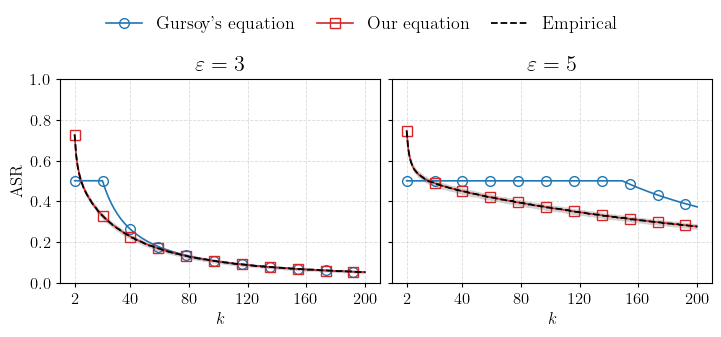

In [5]:
FIG_WIDTH = 7.1
FIG_HEIGHT = 2.8

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],

    # Match the final size in the paper instead of making a huge figure
    "figure.figsize": (FIG_WIDTH, FIG_HEIGHT),

    # Fonts chosen for two-column LaTeX readability
    "font.size": 36,
    "axes.labelsize": 12,
    "axes.titlesize": 16,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 13,

    # Make saved PDF text/lines crisp
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

cmap = plt.get_cmap("tab10")

fig, axes = plt.subplots(
    1, 2,
    figsize=(FIG_WIDTH, FIG_HEIGHT),
    sharey=True,
    constrained_layout=True
)

for ax, epsilon in zip(axes, epsilons):
    old_eps = old[epsilon]
    new_eps = new[epsilon]
    empirical_eps = empirical[epsilon]
    empirical_std_eps = empirical_std[epsilon]

    markevery = max(1, len(range_k) // 10)

    ax.plot(
        range_k,
        old_eps,
        label="Gursoy's equation",
        markevery=markevery,
        markersize=7,
        linewidth=1.2,
        marker="o",
        markerfacecolor="none",
        markeredgecolor=cmap(0),
        color=cmap(0)
    )

    ax.plot(
        range_k,
        new_eps,
        label="Our equation",
        markevery=markevery,
        markersize=7,
        linewidth=1.2,
        marker="s",
        markerfacecolor="none",
        markeredgecolor=cmap(3),
        color=cmap(3)
    )

    ax.plot(
        range_k,
        empirical_eps,
        label="Empirical",
        color="black",
        linewidth=1.3,
        linestyle="--"
    )

    ax.fill_between(
        range_k,
        empirical_eps - empirical_std_eps,
        empirical_eps + empirical_std_eps,
        color="black",
        alpha=0.18,
        linewidth=0
    )

    ax.set_ylim(0, 1)
    ax.set_xticks([2] + list(range(40, max(range_k) + 1, 40)))
    ax.set_xlabel(r"$k$")
    ax.set_title(rf"$\varepsilon = {epsilon}$")
    ax.grid(alpha=0.45, linestyle="--", linewidth=0.6)

    ax.tick_params(axis="both", which="major", length=3, width=0.8)

axes[0].set_ylabel("ASR")

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.18),
    ncol=3,
    frameon=False,
    handlelength=2.0,
    columnspacing=1.2
)

plt.show()